# Growth Analysis

# Phase 1 – Growth Model Analysis

We simulate a Duolingo-style product using:

- 7-state lifecycle Markov model
- Maturity-adjusted transitions
- Gradual A/B rollout
- State + streak-based activity dynamics

This notebook tells the growth story from raw events → KPIs → lifecycle decomposition → experiment impact.

## 📦 1. Load Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import sys

ROOT = Path.cwd().parent          # because we are in /notebooks
DATA_DIR = ROOT / "data"

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR, "exists:", DATA_DIR.exists())
print("CSV files:", [p.name for p in DATA_DIR.glob("*.csv")])

ROOT = Path.cwd().parent   # project root (because notebook is in /notebooks)
sys.path.append(str(ROOT))  # <-- add this line

from src.metrics import (
    compute_dau,
    compute_wau,
    compute_mau,
    compute_retention,
    compute_sessions_per_user,
    compute_lesson_funnel
)

# Load data
users = pd.read_csv(DATA_DIR / "users.csv", parse_dates=["signup_date"])

events = pd.read_csv(DATA_DIR / "events.csv", parse_dates=["event_time"])

sessions = pd.read_csv(DATA_DIR / "sessions.csv", parse_dates=["session_start", "session_end"])

lessons = pd.read_csv(DATA_DIR / "lessons.csv")

print(users.shape, events.shape, sessions.shape, lessons.shape)

ROOT: e:\data_projects\duolingo-growth-model-jinmyung
DATA_DIR: e:\data_projects\duolingo-growth-model-jinmyung\data exists: True
CSV files: ['users.csv', 'sessions.csv', 'events.csv', 'lessons.csv']
(10000, 13) (13953754, 15) (1134726, 7) (256, 7)


We start from raw event-level telemetry.
All product metrics will be computed using a centralized metrics layer to ensure consistency.

## 📈 2. Core Growth Metrics (DAU / WAU / MAU)

In [2]:
dau = compute_dau(events, group_cols=["variant"])
wau = compute_wau(events, group_cols=["variant"])
mau = compute_mau(events, group_cols=["variant"])

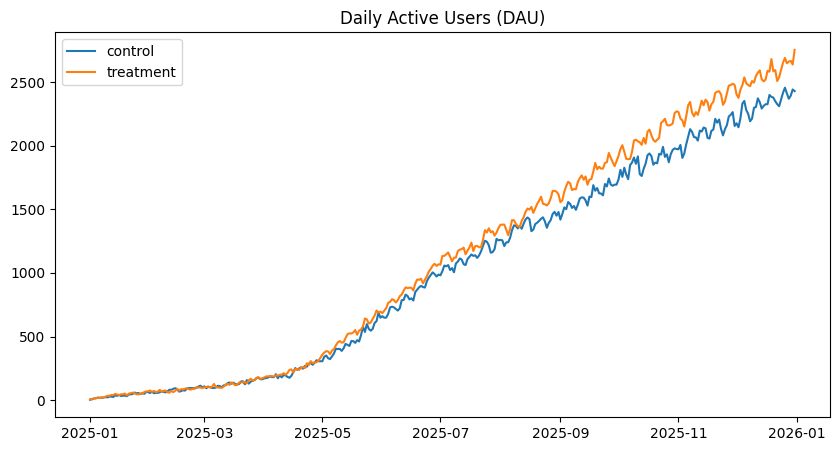

In [3]:
fig, ax = plt.subplots(figsize=(10,5))

for v in dau["variant"].unique():
    sub = dau[dau["variant"] == v]
    ax.plot(sub["date"], sub["dau"], label=v)

ax.set_title("Daily Active Users (DAU)")
ax.legend()
plt.show()

### Observation

1. DAU increases over time as the product matures.
2. Around day ~90, treatment begins diverging from control.
3. The lift peaks mid-year and fades slightly as maturity saturates.

This matches the design in the simulation:
- Treatment ramps in gradually
- Impact fades as baseline retention strengthens

## 🔁 3. Retention Curves

In [4]:
ret = compute_retention(users, events, n_days=[1,7,30], by_variant=True)
ret.head()

,cohort_date,variant,retained_users,day_n,cohort_size,retention_rate
0,2025-01-01,control,5,1,10,0.5
1,2025-01-01,treatment,2,1,10,0.2
2,2025-01-01,control,2,7,10,0.2
3,2025-01-01,treatment,0,7,10,0.0
4,2025-01-01,control,0,30,10,0.0


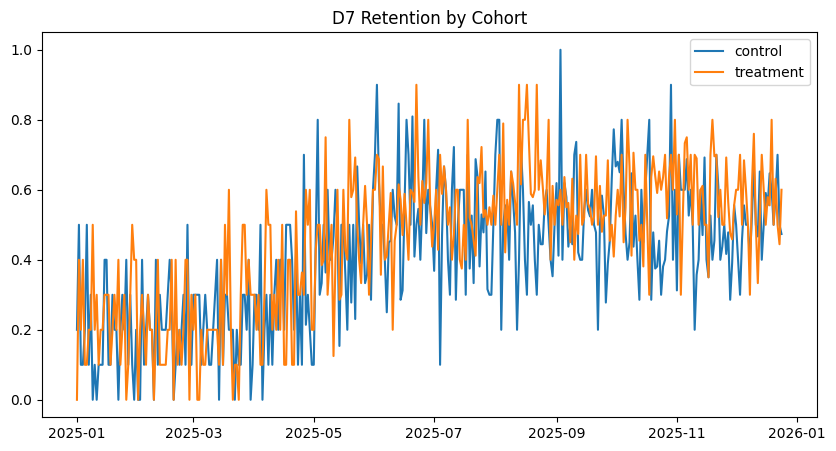

In [5]:
d7 = ret[ret["day_n"] == 7]

fig, ax = plt.subplots(figsize=(10,5))
for v in d7["variant"].unique():
    sub = d7[d7["variant"] == v]
    ax.plot(sub["cohort_date"], sub["retention_rate"], label=v)

ax.set_title("D7 Retention by Cohort")
ax.legend()
plt.show()

### Interpretation

The treatment improves D7 retention most strongly for cohorts
who signed up shortly after rollout.

Later cohorts show smaller relative lift,
consistent with the maturity-weighted treatment effect.

## 🎯 4. Engagement Intensity

In [8]:
sessions_per_user = compute_sessions_per_user(
    sessions,
    events=events,
    users=users,
    group_cols=("variant",),
)

sessions_per_user.head()

,date,variant,sessions,active_users,sessions_per_user
0,2025-01-01,control,3,3,1.000000
1,2025-01-01,treatment,13,6,2.166667
2,2025-01-02,control,13,8,1.625000
3,2025-01-02,treatment,11,6,1.833333
4,2025-01-03,control,18,13,1.384615


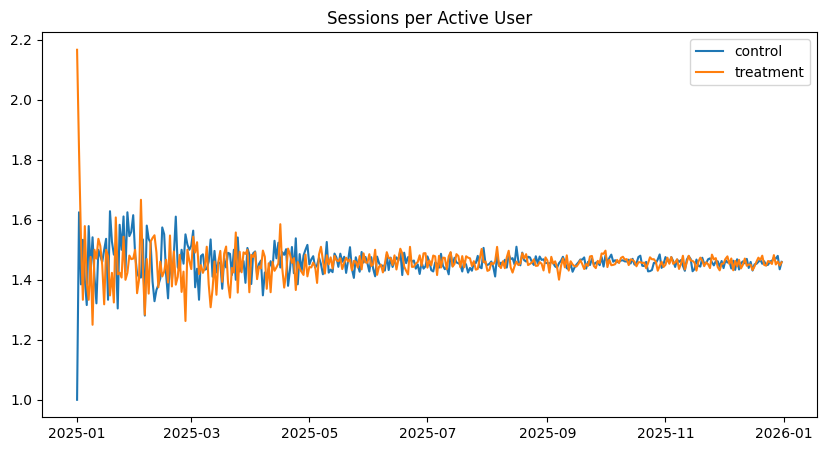

In [9]:
fig, ax = plt.subplots(figsize=(10,5))
for v in sessions_per_user["variant"].unique():
    sub = sessions_per_user[sessions_per_user["variant"] == v]
    ax.plot(sub["date"], sub["sessions_per_user"], label=v)

ax.set_title("Sessions per Active User")
ax.legend()
plt.show()

The experiment does not only increase activity probability —
it also strengthens streak feedback.

This creates:
treatment → stronger habit → more frequent returns → more sessions

## 🧩 5. Lesson Funnel

In [10]:
funnel = compute_lesson_funnel(
    events,
    by="date",
    group_cols=["variant"]
)

funnel.head()

,date,variant,n_signup,n_app_open,n_lesson_started,n_lesson_completed,cr_app_open_given_signup,cr_lesson_started_given_app_open,cr_lesson_completed_given_lesson_started
0,2025-01-01,control,10,3,2,2,0.3,0.666667,1.000
1,2025-01-01,treatment,10,6,5,4,0.6,0.833333,0.800
2,2025-01-02,control,10,8,8,7,0.8,1.000000,0.875
3,2025-01-02,treatment,10,6,6,6,0.6,1.000000,1.000
4,2025-01-03,control,10,13,11,11,1.3,0.846154,1.000


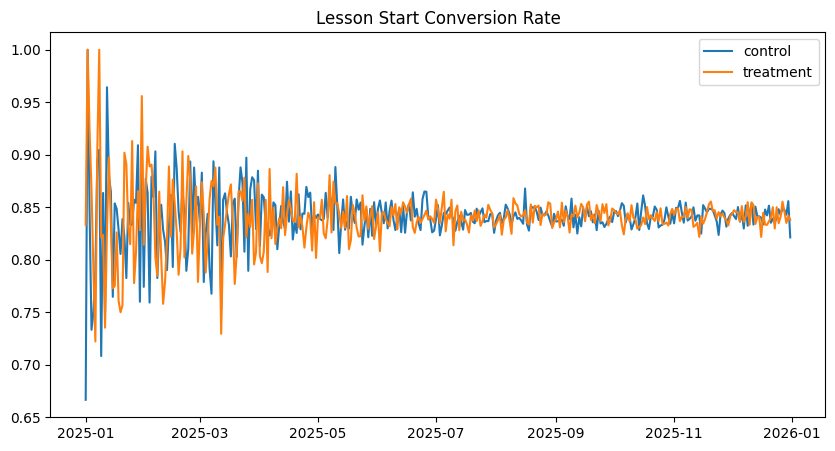

In [11]:
fig, ax = plt.subplots(figsize=(10,5))

for v in funnel["variant"].unique():
    sub = funnel[funnel["variant"] == v]
    ax.plot(sub["date"], sub["cr_lesson_started_given_app_open"], label=v)

ax.set_title("Lesson Start Conversion Rate")
ax.legend()
plt.show()

The experiment improves downstream engagement primarily through:
- increased activity probability
- increased streak persistence

Funnel conversion remains stable —
suggesting the lift is behavioral, not UI-driven.

## 🧮 6. Lifecycle Decomposition (Advanced Story)

In [12]:
from src.metrics import compute_lifecycle_counts

lifecycle = compute_lifecycle_counts(
    events,
    users,
    group_cols=("variant",),
)

lifecycle.head()

,date,state,users,variant
0,2025-01-01,AtRiskMAU,0,control
1,2025-01-01,AtRiskWAU,0,control
2,2025-01-01,Current,0,control
3,2025-01-01,Dormant,0,control
4,2025-01-01,New,10,control


In [13]:
pivot = lifecycle.pivot_table(
    index="date",
    columns=["variant","state"],
    values="users"
)

In [14]:
state_name_map = {
    "New": "New",
    "Current": "Current",
    "Reactivated": "Reactivated",
    "Resurrected": "Resurrected",
    "AtRiskWAU": "At Risk WAU",
    "AtRiskMAU": "At Risk MAU",
    "Dormant": "Dormant",
}

lifecycle["state"] = lifecycle["state"].map(state_name_map)
lifecycle.head(20)

,date,state,users,variant
0,2025-01-01,At Risk MAU,0,control
1,2025-01-01,At Risk WAU,0,control
2,2025-01-01,Current,0,control
3,2025-01-01,Dormant,0,control
4,2025-01-01,New,10,control
5,2025-01-01,Reactivated,0,control
6,2025-01-01,Resurrected,0,control
7,2025-01-01,At Risk MAU,0,treatment
8,2025-01-01,At Risk WAU,0,treatment
9,2025-01-01,Current,0,treatment


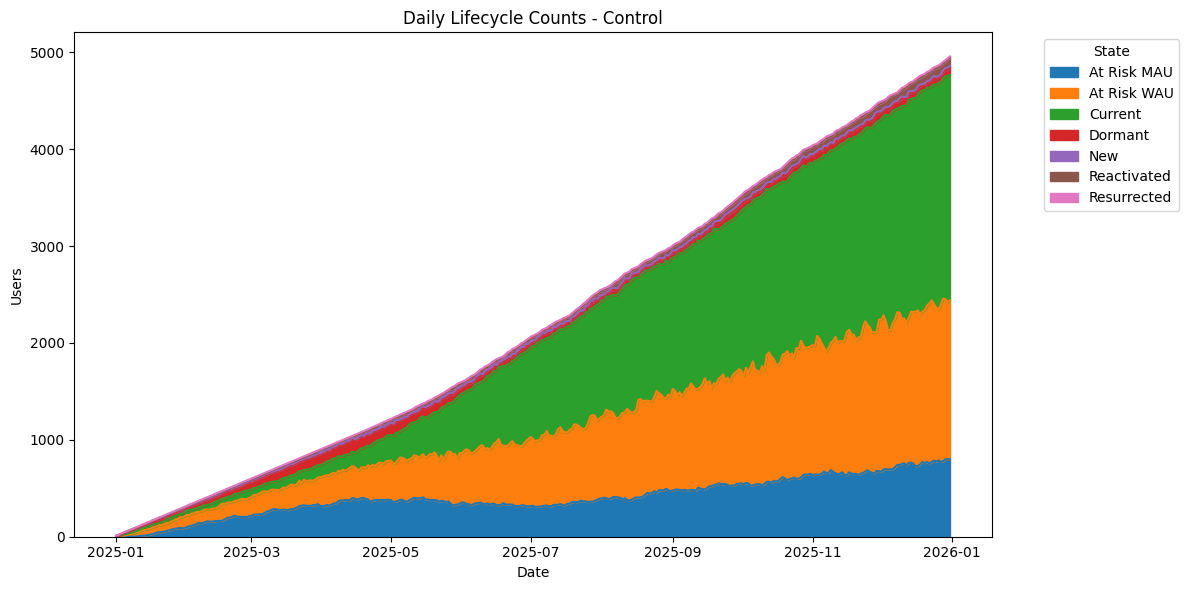

In [15]:
plot_df = (
    lifecycle[lifecycle["variant"] == "control"]
    .pivot(index="date", columns="state", values="users")
    .fillna(0)
)

plot_df.plot.area(figsize=(12, 6))
plt.title("Daily Lifecycle Counts - Control")
plt.xlabel("Date")
plt.ylabel("Users")
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

DAU growth decomposes into:

- New users (acquisition)
- Current users (retained core)
- Reactivated users (win-backs)
- Resurrected users (deep churn recovery)

The treatment primarily shifts users from:
AtRisk → Current
Dormant → Current

Exactly as defined in the transition-matrix mass shift.

## 🎬 7. Final Story Slide (Executive Summary)

# Phase 1 Conclusion

The simulation demonstrates:

1. Smooth product maturity curve
2. Realistic lifecycle transitions
3. Gradual A/B rollout
4. Habit-formation mechanism via streak sensitivity

The experiment produces:
- Higher DAU
- Improved D7 retention
- Increased session frequency
- Lifecycle rebalancing toward Current users

Importantly:
Treatment impact fades as baseline product maturity increases,
mirroring real-world diminishing returns.